In [2]:
import torch

#### 2.5.1 A Simple Function

In [2]:
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [3]:
# Can also create x = torch.arange(4.0, requires_grad=True)
x.requires_grad_(True)
x.grad  # The gradient is None by default
# 当x为一个requires_grad=True，即需要计算梯度的张量时，后续根据x得到的y将自动追踪x的计算历史， 以便后续反向传播求导。

In [4]:
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

In [5]:
y.backward()    
x.grad

tensor([ 0.,  4.,  8., 12.])

In [6]:
x.grad == 4 * x

tensor([True, True, True, True])

In [7]:
x.grad.zero_()  # Reset the gradient
y = x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1.])

#### 2.5.2 Backward for Non-Scalar Variables

In [8]:
x.grad.zero_()
y = x * x
y.backward(gradient=torch.ones(len(y)))  # Faster: y.sum().backward()
x.grad
# zero_() 原地操作函数，将直接修改x.grad的值为0
# gradient参数，与y形状相同，用于指定梯度的权重，否则pytorch无法计算backward

tensor([0., 2., 4., 6.])

#### 2.5.3 Detaching Computation

In [9]:
x.grad.zero_()
y = x * x
u = y.detach()
z = u * x

z.sum().backward()
x.grad == u

tensor([True, True, True, True])

In [10]:
x.grad.zero_()
y.sum().backward()
x.grad == 2 * x

tensor([True, True, True, True])

#### 2.5.4 Gradients and Python Control Flow

In [11]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

In [12]:
a = torch.randn(size=(), requires_grad=True)
d = f(a)
d.backward()

In [13]:
a.grad == d / a, a.grad.zero_()  # 加上该词句以反复运行该段落与上一段落
# 反复运行该段落与上一段落，可以看到，运行结果时而为True时而为False
# 考察f(x)函数发现，该函数并非教材中所说的是一个线性函数

(tensor(True), tensor(0.))

##### exercise_1
First, in order to compute second derivative, we need to compute the first derivative.  
And usually, the second derivative is more complex than the first.  
Second, when computing a multi-parameter funtion, the result of second derivative is a matrix.  
While the result of the first derivative is a vector as large as the variation.

In [15]:
# exercise_2
x_exe_2 = torch.arange(4.0, requires_grad=True)
y_exe_2 = 3 * torch.dot(x_exe_2, x_exe_2)

In [16]:
# exercise_2
#y_exe_2.backward()
y_exe_2.backward(retain_graph=True)
x_exe_2.grad

## Without retain_graph=True, we could not access computation graph a second time, for it is deleted automatically.
## After adding retain_graph=True, we notice that the gradient is a summation.

tensor([ 0.,  6., 12., 18.])

In [7]:
# exercise_3
# vector
a = torch.randn(size=(3,), requires_grad=True)
d = 2 * a * a
d.sum().backward()
a.grad
## Intrestingly, size=(3) or size=3 leads to TypeError.
## That is because 3 or (3) is considered as int but (3,) is considered as a cell with a single element.
## Simply turning a into a vector leads to RuntimeError, grad can be implicitly created only for scalar outputs.
## Invoking sum() between d and backward() helps.

tensor([-0.5291, -6.1586,  3.1277])

In [8]:
# exercise_3
# matrix
a = torch.randn(size=(2,3), requires_grad=True)
d = 2 * a * a
d.sum().backward()
a.grad
## Simply turning a into a vector leads to RuntimeError, grad can be implicitly created only for scalar outputs.
## Invoking sum() between d and backward() helps.

tensor([[-1.5895,  0.8667, -1.1496],
        [-4.2708, -1.9833, -0.6691]])

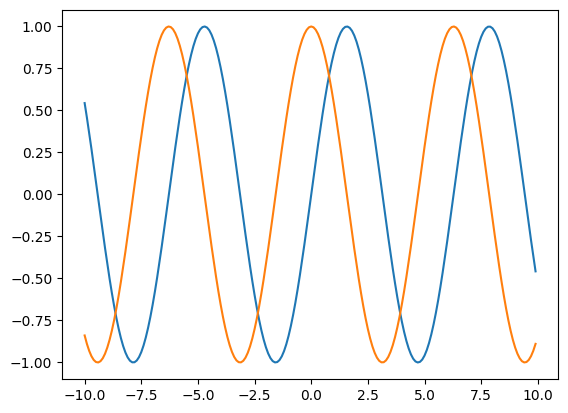

In [17]:
# exercise_4
import numpy as np
import matplotlib.pyplot as plt
def f(x):
    return torch.sin(x)
x = torch.arange(-10, 10, 0.1, requires_grad=True)
f(x).sum().backward()
plt.plot(x.detach().numpy(), f(x).detach().numpy(), label='f(x)')
plt.plot(x.detach().numpy(), x.grad.detach().numpy(), label='Derivative line')

##### exercise_5
x -> x^2 -> log(x^2) -> log(x^2))*sin(x) -> f(x)  
      sin(x)          ->                      
      1/x                                   ->

##### exercise_6
g_1(x) = log(x^2)*sin(x)  
g_2(x) = 1/x  
h_1(x) = log(x^2)  
h_2(x) = sin(x)  
k(x) = x^2  
df/dx = df/dg_1 * dg_1/dx + df/dg_2 * dg_2/dx  
      = df/dg_1 * dg_1/dh_1 * dh_1/dx + df/dg_2 * dg_2/dx  
      = df/dg_1 * (dg_1/dh_1 * dh_1/dx + dg_1/dh_2 * dh_2/dx) + df/dg_2 * dg_2/dx

##### exercise_8
forward: simpler, smaller, timely function  
backward: using chain rule to compute complex fuctions efficiently  
           throwing medi-results while computing backward to minimize storage  
           using previous data, the result is not timely